# Practical Statistics for Research Projects

This notebook explores practical statistical concepts using a simulated dataset. Topics covered include:
- Exploratory Data Analysis (Central Tendency, Variation, Correlation)
- Sampling Distributions
- Examination of Variances
- T-test (between two groups)
- ANOVA (between three groups)
- Effect Size Estimation
- Simple Linear Regression Models
- Multiple Linear Regression Models

To examine these topics we're going to use a simulated dataset which tracks the growth of three groups of plants (Control, Fertilizer A, Fertilizer B) at week 0 and at week 6 along with several other variables including leaf count, sunlight hours, and water amounts.

_____________________________________________________________________________


Research Question: Does fertilizer affect plant growth over a 6 week period?

## Dataset Overview

Let's take a look at the first few rows of our plant growth dataset.

In [ ]:
## import the packages needed for the basic analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## read in the CSV file
try:
  df = pd.read_csv('plant_growth_fertilizer.csv')
except:
  !wget https://raw.githubusercontent.com/ampivirotto/virtual_workshops/refs/heads/main/practical_stats/plant_growth_fertilizer.csv

  df = pd.read_csv('plant_growth_fertilizer.csv')
df

--2026-07-15 16:12:10--  https://raw.githubusercontent.com/ampivirotto/virtual_workshops/refs/heads/main/practical_stats/plant_growth_fertilizer.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2543 (2.5K) [text/plain]
Saving to: ‘plant_growth_fertilizer.csv’

plant_growth_fertil 100%[===================>]   2.48K  --.-KB/s    in 0s      

2026-07-15 16:12:11 (29.1 MB/s) - ‘plant_growth_fertilizer.csv’ saved [2543/2543]



,plant_id,treatment,initial_height_cm,final_height_cm,growth_cm,leaf_count,sunlight_hours,water_ml_per_day
0,P001,Control,10.2,15.1,4.9,12,6.1,98
1,P002,Control,9.8,14.2,4.4,11,5.8,102
2,P003,Control,11.1,16.4,5.3,13,6.3,100
3,P004,Control,10.5,15.0,4.5,12,5.9,95
4,P005,Control,9.7,13.9,4.2,10,5.6,97
5,P006,Control,10.9,15.8,4.9,13,6.2,101
6,P007,Control,11.4,16.1,4.7,12,6.0,99
7,P008,Control,10.1,14.6,4.5,11,5.7,96
8,P009,Control,9.5,13.8,4.3,10,5.5,94
9,P010,Control,10.8,15.6,4.8,12,6.1,103


## Exploratory Data Analysis

### Review from previous weeks

In [ ]:
location_stats = df.groupby('treatment')[['growth_cm']].agg(['mean', 'median'])
display(location_stats)

growth_cm       
                  mean median
treatment                    
Control          4.645   4.70
Fertilizer_A     6.975   7.05
Fertilizer_B     8.845   8.80

In [ ]:
variation_stats = df.groupby('treatment')[['growth_cm']].agg(['std', 'var', 'min', 'max'])
display(variation_stats)

growth_cm                    
                   std       var  min  max
treatment                                 
Control       0.331623  0.109974  4.1  5.3
Fertilizer_A  0.482183  0.232500  6.1  7.7
Fertilizer_B  0.527631  0.278395  7.8  9.7

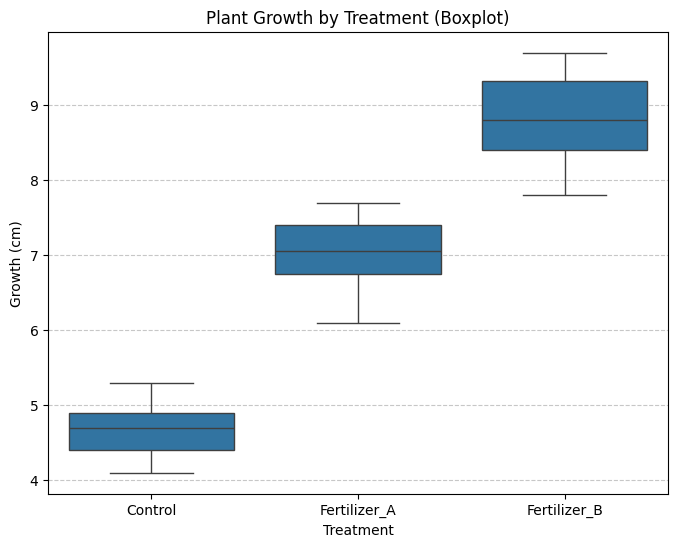

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='treatment', y='growth_cm', data=df)
plt.title('Plant Growth by Treatment (Boxplot)')
plt.xlabel('Treatment')
plt.ylabel('Growth (cm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Try exploring a different variable other than growth in the cells below.

## Exploratory Data Analysis

### Correlation

<Axes: xlabel='sunlight_hours', ylabel='growth_cm'>

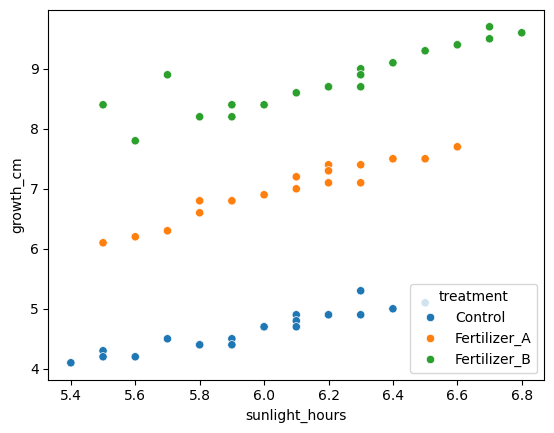

In [ ]:
sns.scatterplot(data = df, x = 'sunlight_hours', y='growth_cm', hue='treatment')

In [ ]:
correlation_by_treatment = df.groupby('treatment')[['sunlight_hours', 'growth_cm']].corr().unstack().iloc[:, 1]
display(correlation_by_treatment)

,sunlight_hours
,growth_cm
treatment,
Control,0.942878
Fertilizer_A,0.967761
Fertilizer_B,0.893200


## Sampling Distribution

In [ ]:
from scipy import stats
import numpy as np

# Calculate mean, standard deviation, and count for each treatment group
grouped_stats = df.groupby('treatment')['growth_cm'].agg(['mean', 'std', 'count'])

confidence_intervals = {}
alpha = 0.05 # For 95% confidence interval

for treatment, row in grouped_stats.iterrows():
    mean = row['mean']
    std = row['std']
    n = row['count']

    # Calculate Standard Error of the Mean (SEM)
    sem = std / np.sqrt(n)

    # Calculate the t-critical value for a 95% confidence interval
    # Degrees of freedom = n - 1
    t_critical = stats.t.ppf(1 - alpha/2, df=n-1)

    # Calculate the margin of error
    margin_of_error = t_critical * sem

    # Calculate the confidence interval
    lower_bound = mean - margin_of_error
    upper_bound = mean + margin_of_error

    confidence_intervals[treatment] = (lower_bound, upper_bound)

print("95% Confidence Intervals for Mean Plant Growth (cm) by Treatment:")
for treatment, ci in confidence_intervals.items():
    print(f"  {treatment}: ({ci[0]:.2f}, {ci[1]:.2f})")

95% Confidence Intervals for Mean Plant Growth (cm) by Treatment:
  Control: (4.49, 4.80)
  Fertilizer_A: (6.75, 7.20)
  Fertilizer_B: (8.60, 9.09)


## Statistical Inference

Levene's Test is a statistical test used to assess the equality of variances across different groups. This assumption, known as homogeneity of variances (or homoscedasticity), is crucial for many parametric statistical tests, particularly the Analysis of Variance (ANOVA).

**Why is it used?**

- Assumption for Parametric Tests: Tests like ANOVA assume that the variance of the dependent variable is roughly equal across all groups being compared. If this assumption is violated, the p-values for these tests can be inaccurate, potentially leading to incorrect conclusions.
- Robustness: While ANOVA is somewhat robust to minor violations of homogeneity of variances, especially with equal sample sizes, severe violations can significantly inflate or deflate the Type I error rate (false positives).
- Interpretation: If Levene's test indicates unequal variances, it suggests that the spread of data in at least one group is significantly different from the others. In such situations, you might consider:
  - Data Transformation: Applying a transformation (e.g., logarithmic, square root) to the dependent variable to stabilize the variances.
  - Non-parametric Tests: Using alternative non-parametric tests that do not assume homogeneity of variances (e.g., Welch's ANOVA, Kruskal-Wallis H-test).
  - Adjustments: Using modified versions of parametric tests that account for unequal variances (like Welch's ANOVA, which is a variant of ANOVA that doesn't assume equal variances).


In [ ]:
from scipy.stats import levene

# Extract growth data for each treatment group
control_growth = df[df['treatment'] == 'Control']['growth_cm']
fertilizer_a_growth = df[df['treatment'] == 'Fertilizer_A']['growth_cm']
fertilizer_b_growth = df[df['treatment'] == 'Fertilizer_B']['growth_cm']

# Perform Levene's test
statistic, p_value = levene(control_growth, fertilizer_a_growth, fertilizer_b_growth)

print(f"Levene's Test Statistic: {statistic:.2f}")
print(f"Levene's Test p-value: {p_value:.3f}")

# Interpret the p-value
alpha = 0.05 # Significance level
if p_value < alpha:
    print("\nBased on Levene's test, we reject the null hypothesis. There is a significant difference in variances between the groups (variances are not equal).")
    print("This suggests that the assumption of homogeneity of variances is violated, which may impact the validity of some parametric tests like ANOVA.")
else:
    print("\nBased on Levene's test, we fail to reject the null hypothesis. There is no significant difference in variances between the groups (variances are equal).")
    print("This suggests that the assumption of homogeneity of variances is met, and parametric tests like ANOVA can be used.")

Levene's Test Statistic: 2.20
Levene's Test p-value: 0.120

Based on Levene's test, we fail to reject the null hypothesis. There is no significant difference in variances between the groups (variances are equal).
This suggests that the assumption of homogeneity of variances is met, and parametric tests like ANOVA can be used.


Now let's take a look at the distributions of the growth amounts for each treatment group to visually inspect the variances.

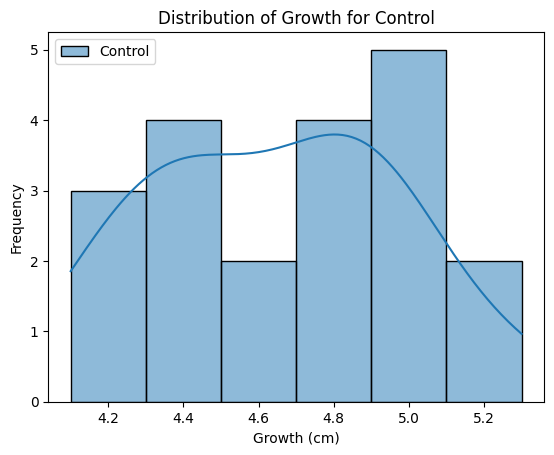

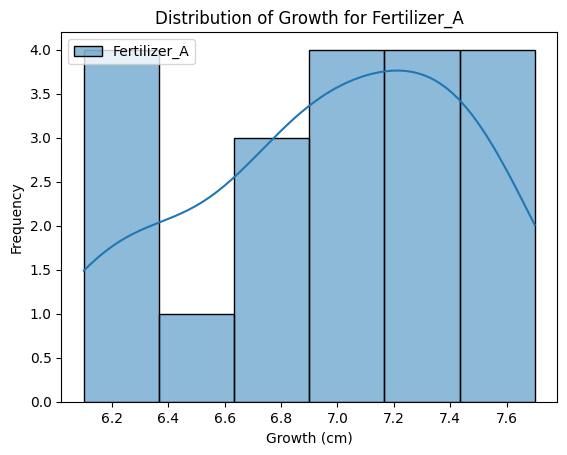

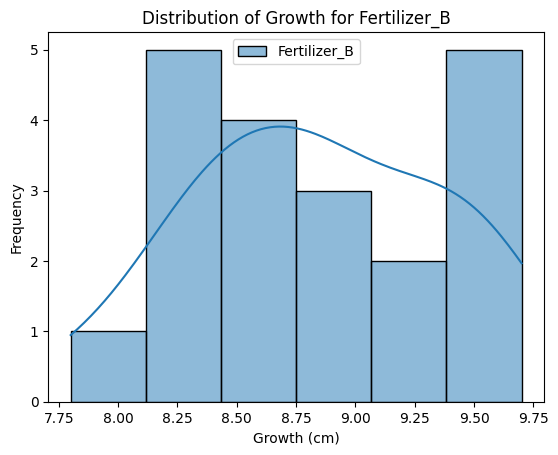

In [ ]:
for treatment in df['treatment'].unique():
  subset = df[df['treatment'] == treatment]
  sns.histplot(subset['growth_cm'], label=treatment, kde=True)
  plt.legend()
  plt.title(f'Distribution of Growth for {treatment}')
  plt.xlabel('Growth (cm)')
  plt.ylabel('Frequency')
  plt.show()

### T-test

A t-test is a statistical hypothesis test that is typically used to determine if there is a significant difference between the means of two groups. It's particularly useful when you have a small sample size or you don't know the population standard deviation.

**When is a t-test usually used?**

1. **Comparing two independent means:** This is the most common use case. For example, comparing the average growth of plants treated with Fertilizer A versus those treated with Fertilizer B (assuming the groups are independent).
2. **Comparing a sample mean to a known population mean (one-sample t-test):** If you have a known population mean and you want to see if your sample's mean is significantly different from it. For example, comparing the average growth of your control group to a known historical average growth for plants without fertilizer.
3. **Comparing two related (paired) means:** This is used when you have two measurements from the same subjects or matched pairs. For instance, comparing the initial height of plants to their final height, or comparing the effectiveness of a treatment before and after application on the same group of plants.

#### Students's t-test: Control vs. Fertilizer A

Note if non equal variances you can perform a Welch's t-test by flaging equal_var = False within the function.

In [ ]:
from scipy.stats import ttest_ind

# Extract growth data for Control and Fertilizer_A
control_growth = df[df['treatment'] == 'Control']['growth_cm']
fertilizer_a_growth = df[df['treatment'] == 'Fertilizer_A']['growth_cm']

# Perform Student's t-test (ttest_ind with equal_var=False if needed (non equal variances))
t_statistic, p_value = ttest_ind(control_growth, fertilizer_a_growth)

print(f"Student's's t-statistic: {t_statistic:.3f}")
print(f"p-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in mean plant growth between the Control group and Fertilizer A group.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than alpha ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean plant growth between the Control group and Fertilizer A group.")

Student's's t-statistic: -17.806
p-value: 0.000

Since the p-value (0.000) is less than alpha (0.05), we reject the null hypothesis.
There is a statistically significant difference in mean plant growth between the Control group and Fertilizer A group.


Try this again with the Fertilizer Group B in comparison with the Control samples.

### Introduction to ANOVA (Analysis of Variance)

**What is ANOVA?**

ANOVA, or Analysis of Variance, is a statistical test used to analyze the differences among group means in a sample. It's a powerful tool when you want to compare the means of **three or more** independent groups to see if at least one group mean is statistically different from the others. While it's called 'Analysis of Variance,' its primary goal is to assess differences in means by examining the variance *between* groups relative to the variance *within* groups.

**Why use ANOVA instead of multiple t-tests?**

If you have more than two groups, performing multiple t-tests can increase the probability of making a Type I error (incorrectly rejecting a true null hypothesis). This is known as the **family-wise error rate**. ANOVA controls for this by performing a single test to determine if there's an overall significant difference among the group means.

**Types of ANOVA:**

1.  **One-Way ANOVA:** Used when you have one categorical independent variable (factor) with three or more levels (groups) and one continuous dependent variable. (e.g., comparing plant growth across 'Control', 'Fertilizer A', and 'Fertilizer B' treatments).
2.  **Two-Way ANOVA:** Used when you have two categorical independent variables and one continuous dependent variable. It can assess the main effects of each independent variable and their interaction effect (e.g., comparing plant growth based on 'Fertilizer Type' and 'Sunlight Exposure').
3.  **MANOVA (Multivariate Analysis of Variance):** Used when you have one or more categorical independent variables and **two or more** continuous dependent variables.

If the overall ANOVA test is significant, it tells you that *at least one* group mean is different, but it doesn't tell you *which* specific groups differ. To find this out, you would typically follow up with **post-hoc tests** (e.g., Tukey's HSD, Bonferroni correction) to perform pairwise comparisons while controlling the family-wise error rate.

### One-Way ANOVA: Comparing Growth across All Treatments

In [ ]:
from scipy.stats import f_oneway

# Extract growth data for each treatment group
control_growth = df[df['treatment'] == 'Control']['growth_cm']
fertilizer_a_growth = df[df['treatment'] == 'Fertilizer_A']['growth_cm']
fertilizer_b_growth = df[df['treatment'] == 'Fertilizer_B']['growth_cm']

# Perform One-Way ANOVA
f_statistic, p_value = f_oneway(control_growth, fertilizer_a_growth, fertilizer_b_growth)

print(f"One-Way ANOVA F-statistic: {f_statistic:.3f}")
print(f"One-Way ANOVA p-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in mean plant growth among the treatment groups.")
    print("To find out which specific groups differ, post-hoc tests would be necessary.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than alpha ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean plant growth among the treatment groups.")

One-Way ANOVA F-statistic: 427.881
One-Way ANOVA p-value: 0.000

Since the p-value (0.000) is less than alpha (0.05), we reject the null hypothesis.
There is a statistically significant difference in mean plant growth among the treatment groups.
To find out which specific groups differ, post-hoc tests would be necessary.


### Post-hoc Analysis: Tukey's HSD Test

Since the One-Way ANOVA showed a significant difference among the group means, we perform post-hoc tests to determine which specific pairs of groups are significantly different from each other. Tukey's HSD is a common post-hoc test that controls for the family-wise error rate.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df['growth_cm'], groups=df['treatment'], alpha=0.05)

print(tukey_result)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1       group2    meandiff p-adj lower  upper  reject
-------------------------------------------------------------
     Control Fertilizer_A     2.33   0.0 1.9838 2.6762   True
     Control Fertilizer_B      4.2   0.0 3.8538 4.5462   True
Fertilizer_A Fertilizer_B     1.87   0.0 1.5238 2.2162   True
-------------------------------------------------------------


### Effect Size

**What is Effect Size?**

Effect size is a quantitative measure of the strength of a phenomenon. It provides a more complete picture than p-values alone, as p-values only tell us whether an effect exists, not the magnitude of that effect. A statistically significant result (low p-value) might represent a very small, practically insignificant effect, especially with large sample sizes.

**Why is it Important?**

*   **Practical Significance**: Effect size helps determine if the observed difference or relationship is meaningful in a real-world context, beyond just being statistically significant.
*   **Comparison Across Studies**: It allows researchers to compare the magnitude of effects across different studies, even if they use different measurement scales or sample sizes.
*   **Meta-Analysis**: Effect sizes are the primary statistics used in meta-analyses to synthesize findings from multiple studies.

Different statistical tests have different effect size measures. For ANOVA, we commonly use Eta-squared ($\eta^2$) or Partial Eta-squared ($\eta_p^2$). For pairwise comparisons, Cohen's d is frequently used.

### Eta-squared ($\eta^2$) for ANOVA

Eta-squared ($\eta^2$) is an effect size measure for ANOVA that represents the proportion of variance in the dependent variable that is explained by the independent variable. It ranges from 0 to 1, where a higher value indicates a stronger effect.

*   $\eta^2 = \frac{SS_{between}}{SS_{total}}$

Where:
*   $SS_{between}$ is the sum of squares between groups (variance explained by the treatment).
*   $SS_{total}$ is the total sum of squares (total variance in the dependent variable).

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit the ANOVA model using OLS
model = ols('growth_cm ~ C(treatment)', data=df).fit()

# Perform ANOVA and get the table
anova_table = sm.stats.anova_lm(model, typ=2)

# Extract sums of squares
ss_treatment = anova_table['sum_sq'][0] # Sum of squares for treatment
ss_total = anova_table['sum_sq'].sum() # Total sum of squares

# Calculate Eta-squared
eta_squared = ss_treatment / ss_total

print(f"Eta-squared: {eta_squared:.3f}")

# Interpretation guidance (Cohen, 1988):
# 0.01 = Small effect
# 0.06 = Medium effect
# 0.14 = Large effect

if eta_squared < 0.01:
    interpretation = "very small"
elif eta_squared < 0.06:
    interpretation = "small"
elif eta_squared < 0.14:
    interpretation = "medium"
else:
    interpretation = "large"

print(f"This indicates a {interpretation} effect of treatment on plant growth.")

Eta-squared: 0.938
This indicates a large effect of treatment on plant growth.


/tmp/ipykernel_928/1530279403.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ss_treatment = anova_table['sum_sq'][0] # Sum of squares for treatment


### Cohen's d for Pairwise Comparisons

While Eta-squared gives an overall effect size for ANOVA, it doesn't specify the magnitude of differences between specific pairs of groups. For that, we use **Cohen's d** for pairwise comparisons.

Cohen's d measures the standardized difference between two means. It is calculated as:

*   $d = \frac{\bar{x}_1 - \bar{x}_2}{s_{pooled}}$

Where:
*   $\bar{x}_1$ and $\bar{x}_2$ are the means of the two groups being compared.
*   $s_{pooled}$ is the pooled standard deviation, which combines the standard deviations of both groups.

**Interpretation of Cohen's d (general guidelines by Cohen, 1988):**
*   **0.2**: Small effect
*   **0.5**: Medium effect
*   **0.8**: Large effect

Let's calculate Cohen's d for each pair from the Tukey's HSD test.

In [ ]:
from math import sqrt

# Get the standard deviations for each group from the grouped_stats DataFrame
std_control = grouped_stats.loc['Control', 'std']
std_fertilizer_a = grouped_stats.loc['Fertilizer_A', 'std']
std_fertilizer_b = grouped_stats.loc['Fertilizer_B', 'std']

# Get the counts for each group
n_control = grouped_stats.loc['Control', 'count']
n_fertilizer_a = grouped_stats.loc['Fertilizer_A', 'count']
n_fertilizer_b = grouped_stats.loc['Fertilizer_B', 'count']

# Function to calculate pooled standard deviation
def pooled_std_dev(s1, n1, s2, n2):
    return sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))

# Function to calculate Cohen's d
def cohen_d(mean1, mean2, s_pooled):
    return (mean1 - mean2) / s_pooled

print("Cohen's d for Pairwise Comparisons:")

# Control vs Fertilizer A
mean_control = grouped_stats.loc['Control', 'mean']
mean_fertilizer_a = grouped_stats.loc['Fertilizer_A', 'mean']
sp_ca = pooled_std_dev(std_control, n_control, std_fertilizer_a, n_fertilizer_a)
d_ca = cohen_d(mean_fertilizer_a, mean_control, sp_ca)
print(f"  Fertilizer A vs Control: {d_ca:.3f} (\"{'Large' if abs(d_ca) >= 0.8 else 'Medium' if abs(d_ca) >= 0.5 else 'Small' if abs(d_ca) >= 0.2 else 'Very Small'}\" effect)")

# Control vs Fertilizer B
mean_fertilizer_b = grouped_stats.loc['Fertilizer_B', 'mean']
sp_cb = pooled_std_dev(std_control, n_control, std_fertilizer_b, n_fertilizer_b)
d_cb = cohen_d(mean_fertilizer_b, mean_control, sp_cb)
print(f"  Fertilizer B vs Control: {d_cb:.3f} (\"{'Large' if abs(d_cb) >= 0.8 else 'Medium' if abs(d_cb) >= 0.5 else 'Small' if abs(d_cb) >= 0.2 else 'Very Small'}\" effect)")

# Fertilizer A vs Fertilizer B
sp_ab = pooled_std_dev(std_fertilizer_a, n_fertilizer_a, std_fertilizer_b, n_fertilizer_b)
d_ab = cohen_d(mean_fertilizer_b, mean_fertilizer_a, sp_ab)
print(f"  Fertilizer B vs Fertilizer A: {d_ab:.3f} (\"{'Large' if abs(d_ab) >= 0.8 else 'Medium' if abs(d_ab) >= 0.5 else 'Small' if abs(d_ab) >= 0.2 else 'Very Small'}\" effect)")

Cohen's d for Pairwise Comparisons:
  Fertilizer A vs Control: 5.631 ("Large" effect)
  Fertilizer B vs Control: 9.531 ("Large" effect)
  Fertilizer B vs Fertilizer A: 3.700 ("Large" effect)


### Linear Regression Models

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Define the linear regression model: growth_cm as a function of sunlight_hours
model_linear = ols('growth_cm ~ sunlight_hours', data=df).fit()

# Print the summary of the regression model
print(model_linear.summary())

                            OLS Regression Results                            
Dep. Variable:              growth_cm   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                     18.54
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           6.49e-05
Time:                        16:14:26   Log-Likelihood:                -111.22
No. Observations:                  60   AIC:                             226.4
Df Residuals:                      58   BIC:                             230.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -8.5328      3.572     -2.

The regression summary provides detailed statistics about the model. Key values to look at include:

*   **R-squared**: Indicates the proportion of the variance in the dependent variable (`growth_cm`) that is predictable from the independent variable (`sunlight_hours`).
*   **P-values** (P>|t|): For each coefficient, this tells you if the coefficient is statistically significant (typically, p < 0.05).
*   **Coefficients**: These are the estimated values for the intercept and the slope of `sunlight_hours`.

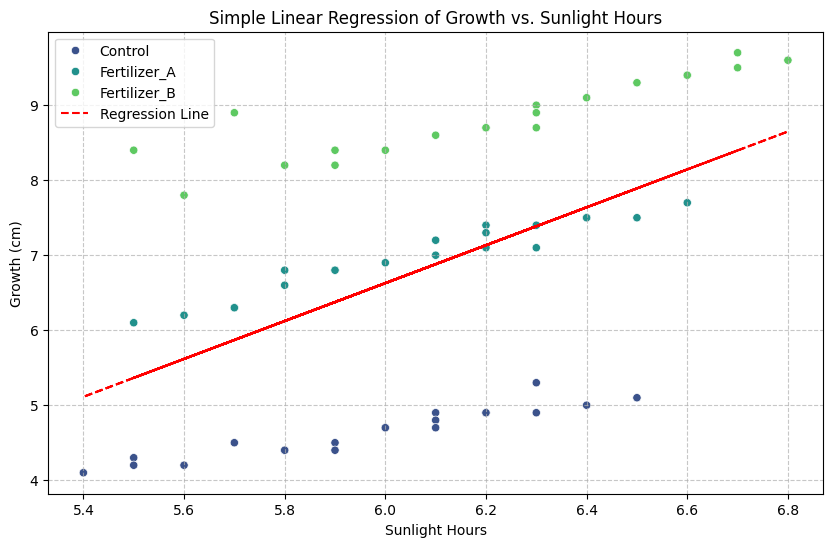

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sunlight_hours', y='growth_cm', data=df, hue='treatment', palette='viridis')
plt.plot(df['sunlight_hours'], model_linear.predict(df['sunlight_hours']), color='red', linestyle='--', label='Regression Line')
plt.title('Simple Linear Regression of Growth vs. Sunlight Hours')
plt.xlabel('Sunlight Hours')
plt.ylabel('Growth (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Multiple Linear Regression

Now, let's expand our regression analysis to include more variables. We will perform a multiple linear regression using `growth_cm` as the dependent variable and `sunlight_hours`, `water_ml_per_day`, and `treatment` as independent variables. Since `treatment` is a categorical variable, `statsmodels` will automatically create dummy variables for it.

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Define the multiple linear regression model
# C(treatment) tells statsmodels to treat 'treatment' as a categorical variable
model_multiple = ols('growth_cm ~ sunlight_hours + water_ml_per_day + C(treatment)', data=df).fit()

# Print the summary of the multiple regression model
print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:              growth_cm   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     1438.
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           6.35e-55
Time:                        16:16:50   Log-Likelihood:                 20.241
No. Observations:                  60   AIC:                            -30.48
Df Residuals:                      55   BIC:                            -20.01
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

### Interpretation of Multiple Linear Regression Results

The summary provides detailed statistics for the multiple regression model. Here's what to look for:

*   **R-squared and Adj. R-squared**: These values indicate the proportion of the variance in `growth_cm` that is explained by the independent variables. A higher value suggests a better fit.
*   **F-statistic and Prob (F-statistic)**: These indicate the overall significance of the model. A low p-value (typically < 0.05) suggests that at least one independent variable is a significant predictor of `growth_cm`.
*   **Coefficients (coef)**: These are the estimated changes in `growth_cm` for a one-unit increase in the corresponding independent variable, holding other variables constant.
    *   For categorical variables like `C(treatment)`, the coefficients represent the difference in `growth_cm` compared to the reference category (usually the first one alphabetically, in this case, 'Control').
*   **P-values (P>|t|)**: For each coefficient, this tells you if that specific independent variable is a statistically significant predictor of `growth_cm` when controlling for the other variables in the model. A p-value less than 0.05 typically indicates significance.

### Checking for Multicollinearity with a Correlation Matrix

Multicollinearity can be an issue in multiple regression, especially when the condition number is high (as noted in the previous model summary). Let's examine the correlation between our independent variables: `sunlight_hours`, `water_ml_per_day`, and the dummy variables created from `treatment`.

Correlation Matrix of Predictors:


,sunlight_hours,water_ml_per_day,treatment_Fertilizer_A,treatment_Fertilizer_B
sunlight_hours,1.000000,0.813936,-0.034098,0.262556
water_ml_per_day,0.813936,1.000000,0.055296,0.209334
treatment_Fertilizer_A,-0.034098,0.055296,1.000000,-0.500000
treatment_Fertilizer_B,0.262556,0.209334,-0.500000,1.000000


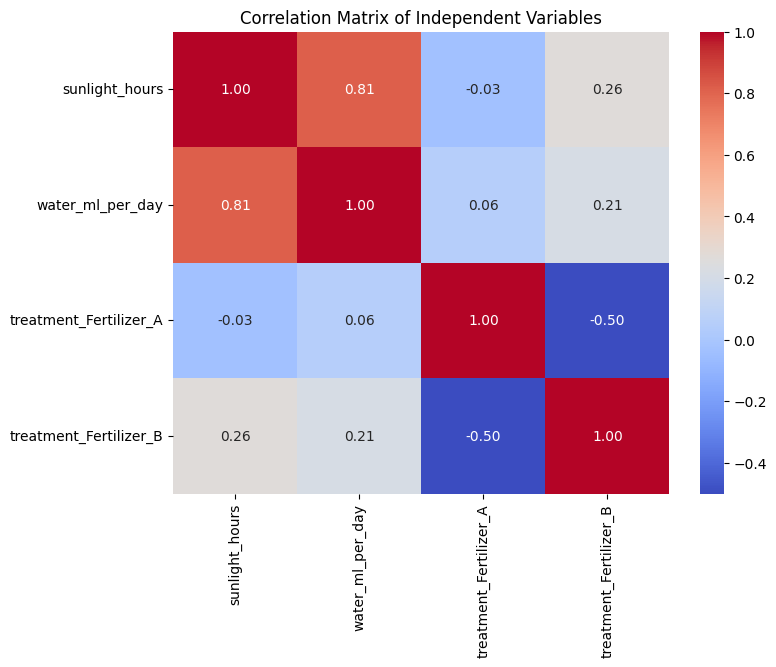

In [ ]:
# Create dummy variables for 'treatment'
df_dummies = pd.get_dummies(df['treatment'], prefix='treatment', drop_first=True)

# Combine with numerical predictors
predictors_df = df[['sunlight_hours', 'water_ml_per_day']].copy()
predictors_df = pd.concat([predictors_df, df_dummies], axis=1)

# Calculate the correlation matrix
correlation_matrix = predictors_df.corr()

# Display the correlation matrix
print("Correlation Matrix of Predictors:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Independent Variables')
plt.show()

### Interpretation of the Correlation Matrix

*   **Values close to +1 or -1** indicate a strong positive or negative linear relationship, respectively. High correlations (e.g., greater than 0.7 or 0.8 in absolute value) between independent variables suggest potential multicollinearity.
*   **Values close to 0** indicate a weak or no linear relationship.

Examine the off-diagonal elements. If you see high correlations between any of your independent variables, it confirms the presence of multicollinearity. While `statsmodels` indicated a high condition number, this heatmap helps us visually pinpoint which variables might be contributing most to this issue.

### Refitting the Multiple Linear Regression (Excluding `water_ml_per_day`)

Given the strong correlation between `sunlight_hours` and `water_ml_per_day`, we will refit the model without `water_ml_per_day` to see if it improves the stability and interpretability of the coefficients.

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Define the multiple linear regression model, excluding 'water_ml_per_day'
# C(treatment) tells statsmodels to treat 'treatment' as a categorical variable
model_refitted = ols('growth_cm ~ sunlight_hours + C(treatment)', data=df).fit()

# Print the summary of the refitted regression model
print(model_refitted.summary())

                            OLS Regression Results                            
Dep. Variable:              growth_cm   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     1927.
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           1.90e-56
Time:                        16:19:13   Log-Likelihood:                 19.850
No. Observations:                  60   AIC:                            -31.70
Df Residuals:                      56   BIC:                            -23.32
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

### Interpretation of the Refitted Multiple Linear Regression Results

Let's examine the summary of the refitted model and compare it to the previous one.

*   **R-squared and Adj. R-squared**: Check if these values remain high, indicating the model still explains a significant portion of the variance in `growth_cm`.
*   **F-statistic and Prob (F-statistic)**: Confirm the overall significance of the model.
*   **Coefficients (coef)**: Observe the estimated effects of `sunlight_hours` and `treatment`.
*   **P-values (P>|t|)**: Assess the statistical significance of each predictor. Look for improvements in the p-values for `sunlight_hours`.
*   **Condition Number**: Crucially, check if the condition number is significantly lower, suggesting that multicollinearity has been reduced and the model is more stable.